In [1]:
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.colors as colors
import geopandas as gpd
from pysheds.grid import Grid
import mplleaflet
# %matplotlib inline

In [20]:
from pysheds.grid import Grid

# Crear el grid y cargar el DEM
grid = Grid()
dem = grid.read_raster('../Rst/20190109125130_1063922483.tif')

# Condition DEM
# ----------------------
# Fill pits in DEM
pit_filled_dem = grid.fill_pits(dem)

# Fill depressions in DEM
flooded_dem = grid.fill_depressions(pit_filled_dem)
    
# Resolve flats in DEM
dem_resolved = grid.resolve_flats(flooded_dem)

dirmap = (64, 128, 1, 2, 4, 8, 16, 32)

# Dirección y acumulación de flujo
flow_dir = grid.flowdir(dem_resolved, dirmap=dirmap)
acc = grid.accumulation(flow_dir, dirmap=dirmap)

# Delimitación de cuenca
catchment = grid.catchment(-107.975, 27.850, flow_dir, recursionlimit=15000)

# Visualización (opcional)
import matplotlib.pyplot as plt
plt.imshow(catchment, cmap='gray')
plt.title("Cuenca delimitada")
plt.show()


ValueError: Pour point (-107.975, 27.85) is out of bounds for dataset with bbox (0.0, 1.0, 1.0, 0.0).

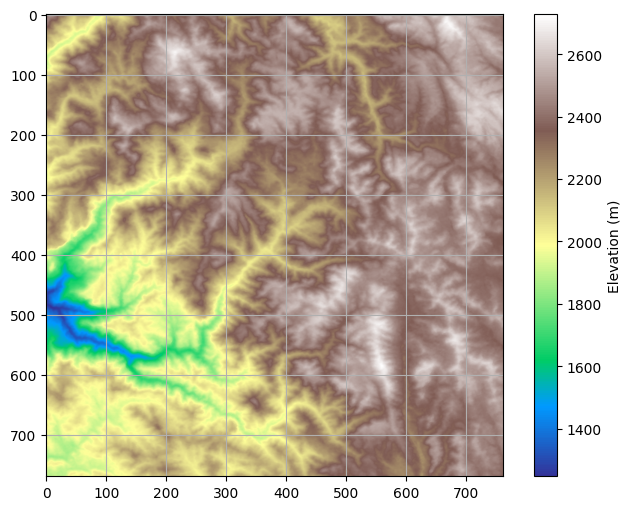

In [21]:
grid = Grid.from_raster('../Rst/20190109125130_1063922483.tif')
dem = grid.read_raster('../Rst/20190109125130_1063922483.tif')

# Visualizar el DEM
def plotFigure(data, label, cmap='terrain'):
    plt.figure(figsize=(8, 6))
    plt.imshow(data, cmap=cmap)
    plt.colorbar(label=label)
    plt.grid()

# Acceder a los datos del DEM correctamente
plotFigure(dem[:-1, :-1], 'Elevation (m)')

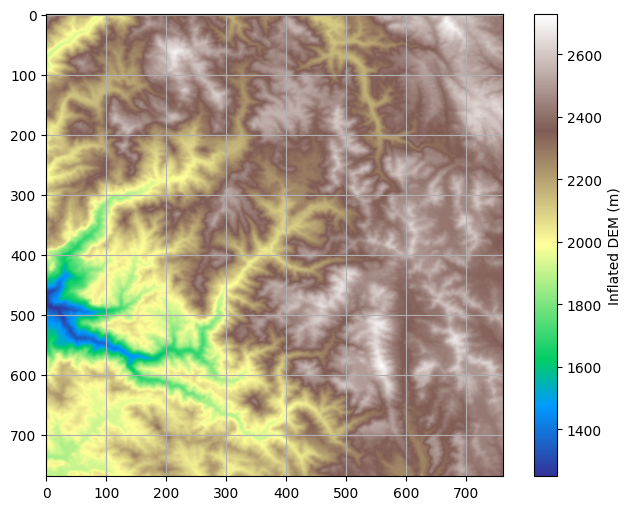

In [22]:
# Condition DEM
# ----------------------
# Fill pits in DEM
pit_filled_dem = grid.fill_pits(dem)

# Fill depressions in DEM
flooded_dem = grid.fill_depressions(pit_filled_dem)
    
# Resolve flats in DEM
inflated_dem = grid.resolve_flats(flooded_dem)


plotFigure(inflated_dem[:-1, :-1], 'Inflated DEM (m)')

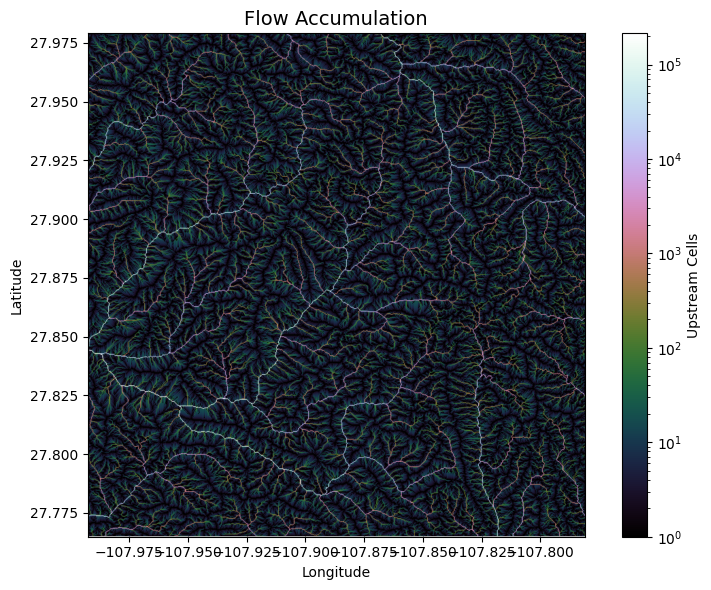

In [23]:
# Determine D8 flow directions from DEM
# ----------------------
# Specify directional mapping
dirmap = (64, 128, 1, 2, 4, 8, 16, 32)
    
# Compute flow directions
# -------------------------------------
fdir = grid.flowdir(inflated_dem, dirmap=dirmap, )

# Calculate flow accumulation
# --------------------------
acc = grid.accumulation(fdir, dirmap=dirmap)


fig, ax = plt.subplots(figsize=(8,6))
fig.patch.set_alpha(0)
plt.grid('on', zorder=0)
im = ax.imshow(acc, extent=grid.extent, zorder=2,
               cmap='cubehelix',
               norm=colors.LogNorm(1, acc.max()),
               interpolation='bilinear')
plt.colorbar(im, ax=ax, label='Upstream Cells')
plt.title('Flow Accumulation', size=14)
plt.xlabel('Longitude')
plt.ylabel('Latitude')
plt.tight_layout()

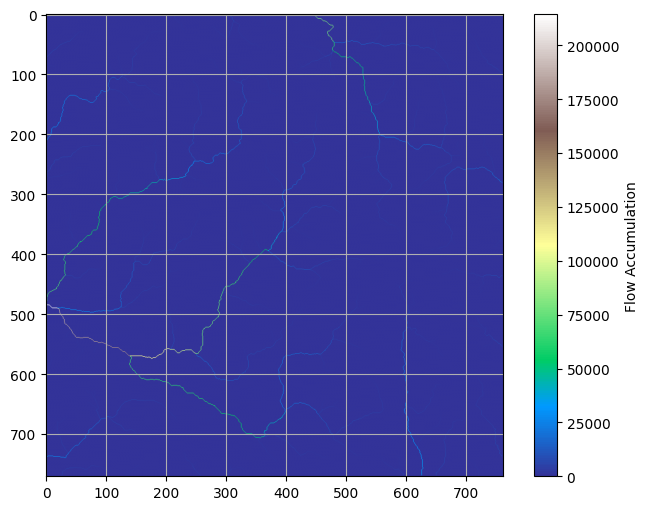

In [25]:
plotFigure(acc, 'Flow Accumulation')

Text(0.5, 1.0, 'Delineated Catchment')

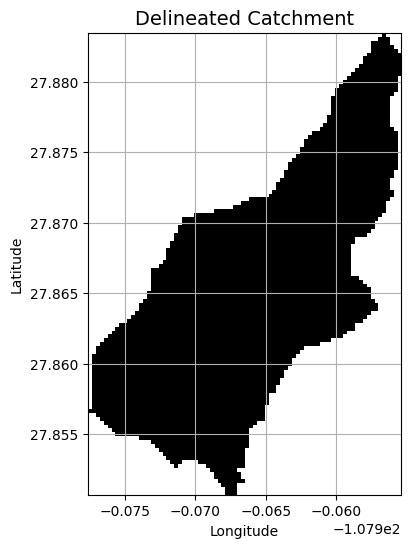

In [26]:
# Delineate a catchment
# ---------------------
# Specify pour point
x, y = -107.975, 27.850

# Snap pour point to high accumulation cell
x_snap, y_snap = grid.snap_to_mask(acc > 1000, (x, y))

# Delineate the catchment
catch = grid.catchment(x=x_snap, y=y_snap, fdir=fdir, dirmap=dirmap, 
                       xytype='coordinate')

# Crop and plot the catchment
# ---------------------------
# Clip the bounding box to the catchment
grid.clip_to(catch)
clipped_catch = grid.view(catch)

# Plot the catchment
fig, ax = plt.subplots(figsize=(8,6))
fig.patch.set_alpha(0)

plt.grid('on', zorder=0)
im = ax.imshow(np.where(clipped_catch, clipped_catch, np.nan), extent=grid.extent,
               zorder=1, cmap='Greys_r')
plt.xlabel('Longitude')
plt.ylabel('Latitude')
plt.title('Delineated Catchment', size=14)

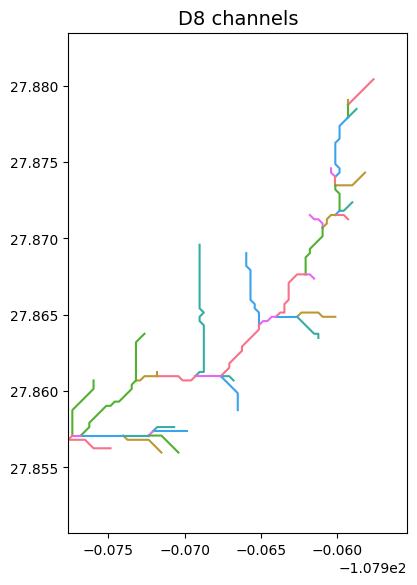

In [28]:
# Extract river network
# ---------------------
import seaborn as sns
branches = grid.extract_river_network(fdir, acc > 50, dirmap=dirmap)
sns.set_palette('husl')
fig, ax = plt.subplots(figsize=(8.5,6.5))

plt.xlim(grid.bbox[0], grid.bbox[2])
plt.ylim(grid.bbox[1], grid.bbox[3])
ax.set_aspect('equal')

for branch in branches['features']:
    line = np.asarray(branch['geometry']['coordinates'])
    plt.plot(line[:, 0], line[:, 1])
    
_ = plt.title('D8 channels', size=14)

Text(0.5, 1.0, 'Flow Distance')

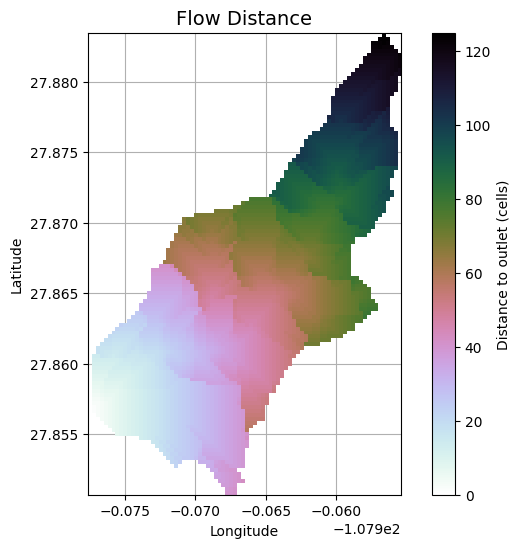

In [29]:
# Calculate distance to outlet from each cell
# -------------------------------------------
dist = grid.distance_to_outlet(x=x_snap, y=y_snap, fdir=fdir, dirmap=dirmap,
                               xytype='coordinate')
fig, ax = plt.subplots(figsize=(8,6))
fig.patch.set_alpha(0)
plt.grid('on', zorder=0)
im = ax.imshow(dist, extent=grid.extent, zorder=2,
               cmap='cubehelix_r')
plt.colorbar(im, ax=ax, label='Distance to outlet (cells)')
plt.xlabel('Longitude')
plt.ylabel('Latitude')
plt.title('Flow Distance', size=14)

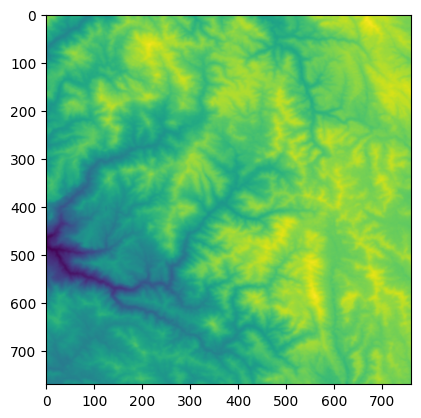

In [ ]:
plt.imshow(dem[:-1,:-1])

In [ ]:
def plotFigure(data, label, cmap='Blues'):
    plt.figure(figsize=(12,10))
    plt.imshow(data, extent=grid.extent)
    plt.colorbar(label=label)
    plt.grid()

In [ ]:
elevDem= dem[:-1,:-1]

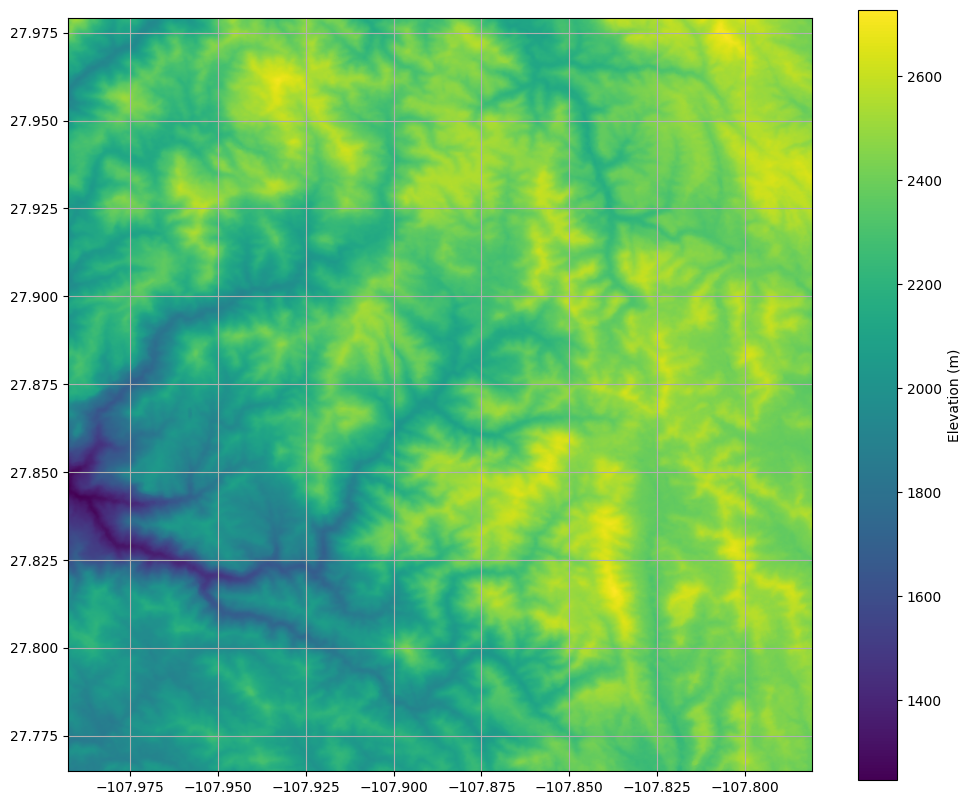

In [ ]:
plotFigure(elevDem, 'Elevation (m)')

In [ ]:
### Detecting depressions

# Detect depressions
sdepressions = grid.detect_depressions(dem)

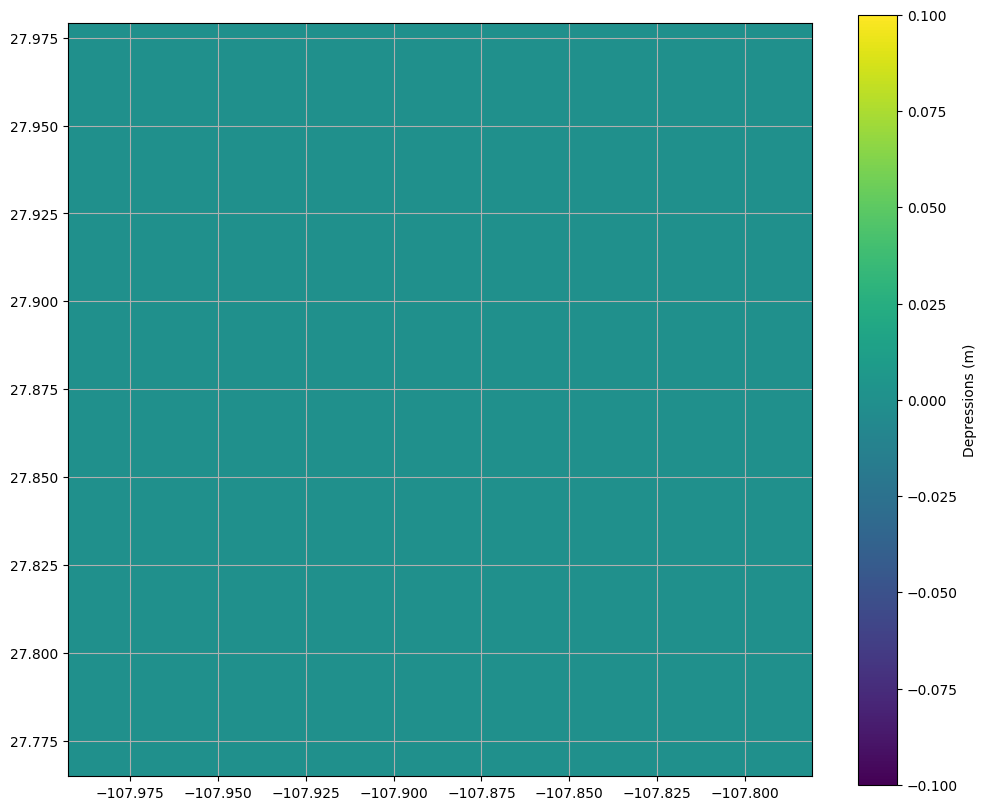

In [ ]:
# Plot depressions
plotFigure(sdepressions[:-1,:-1], 'Depressions (m)')

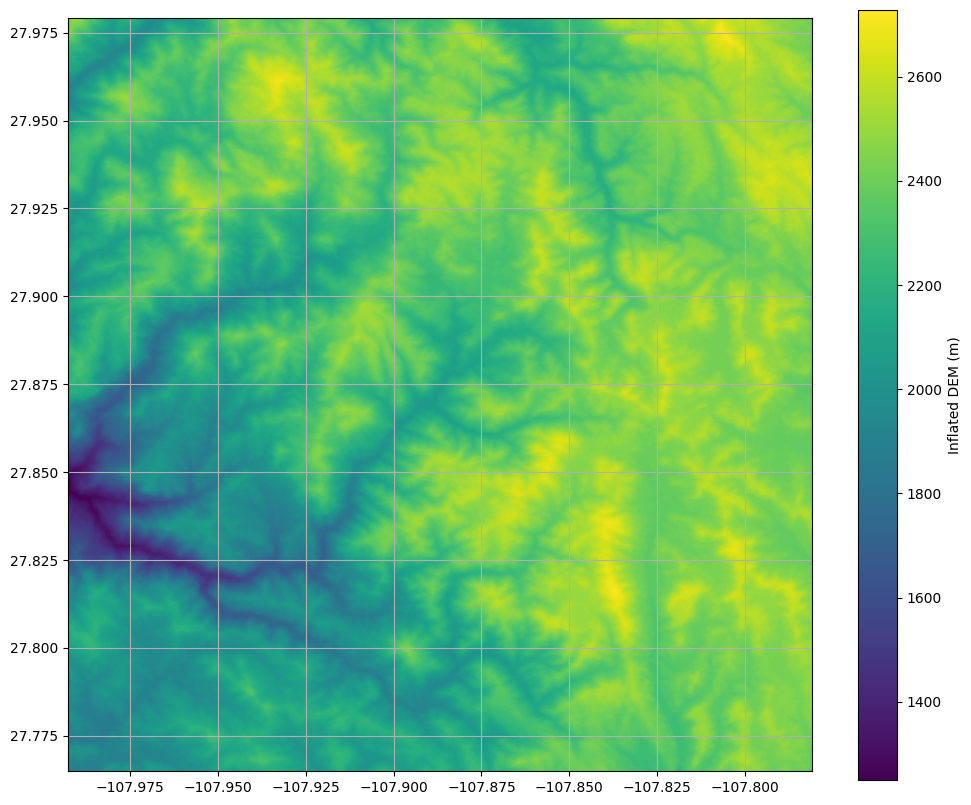

In [ ]:
# Condition DEM
# ----------------------
# Fill pits in DEM
pit_filled_dem = grid.fill_pits(dem)

# Fill depressions in DEM
flooded_dem = grid.fill_depressions(pit_filled_dem)
    
# Resolve flats in DEM
inflated_dem = grid.resolve_flats(flooded_dem)


plotFigure(inflated_dem[:-1, :-1], 'Inflated DEM (m)')

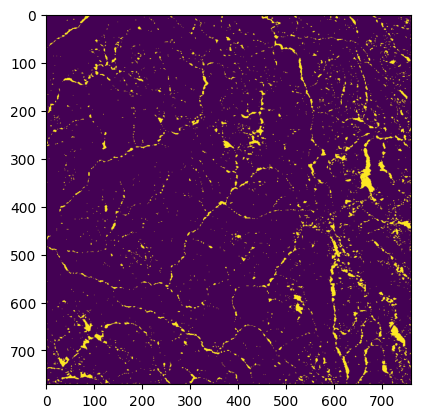

In [ ]:
# Detect flats
flats = grid.detect_flats(flooded_dem)

# Plot flats
plt.imshow(flats)

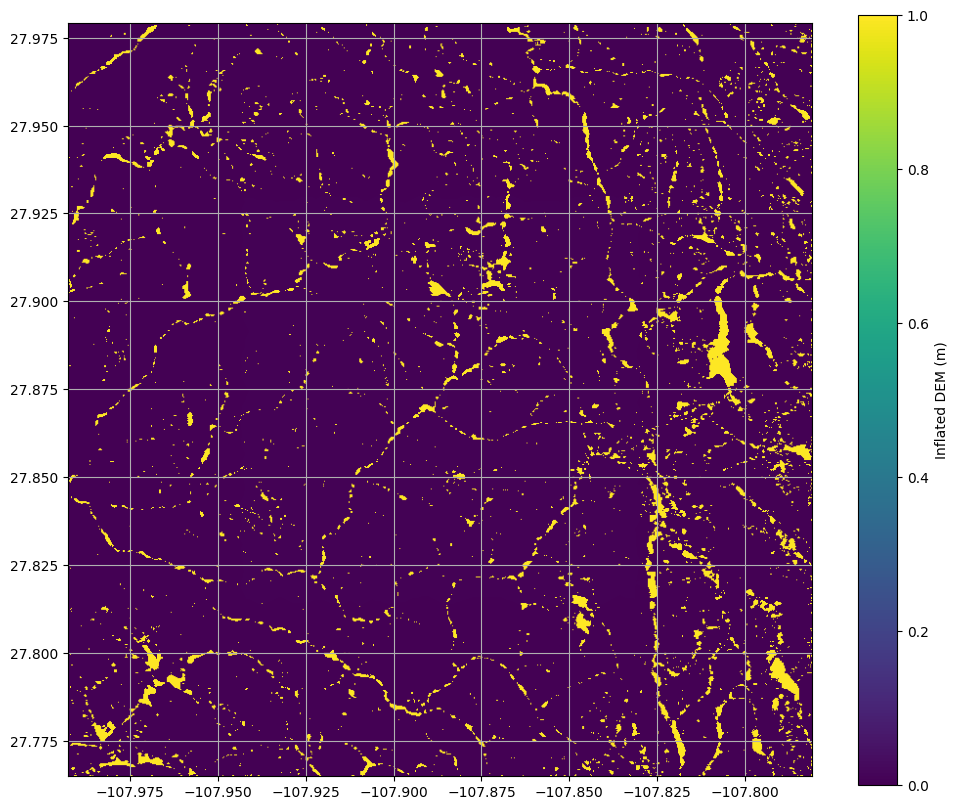

In [ ]:
newflats = grid.resolve_flats(flats)
plotFigure(newflats[:-1, :-1], 'Inflated DEM (m)')

In [ ]:
fdir = grid.flowdir(inflated_dem)

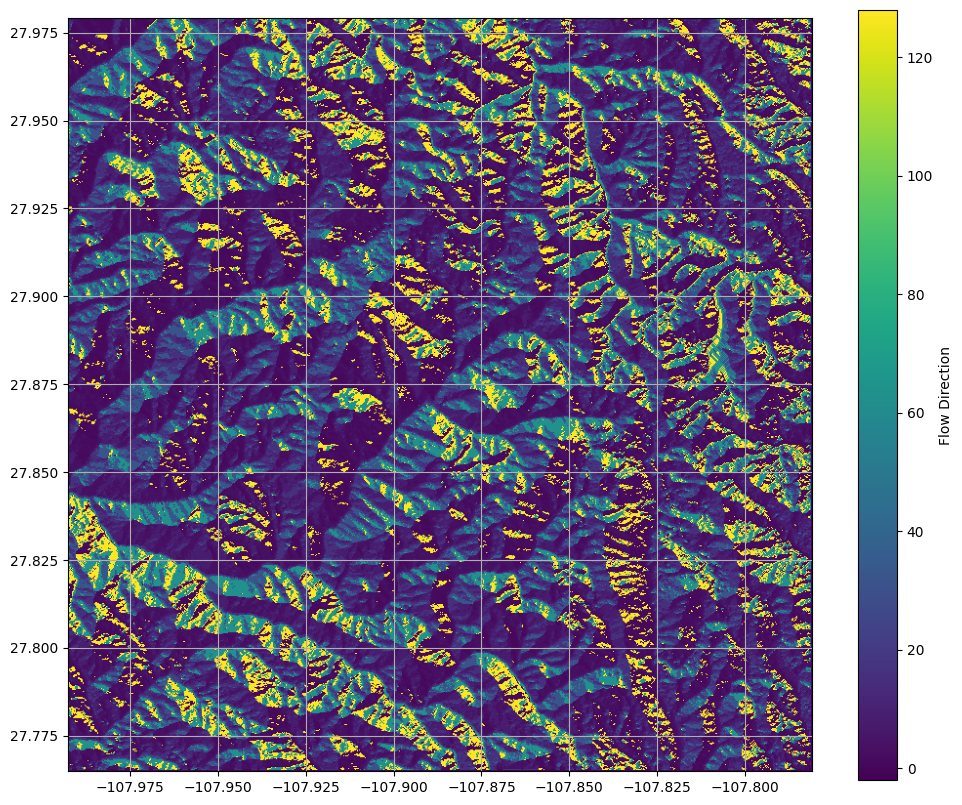

In [ ]:
plotFigure(fdir,'Flow Direction','viridis')

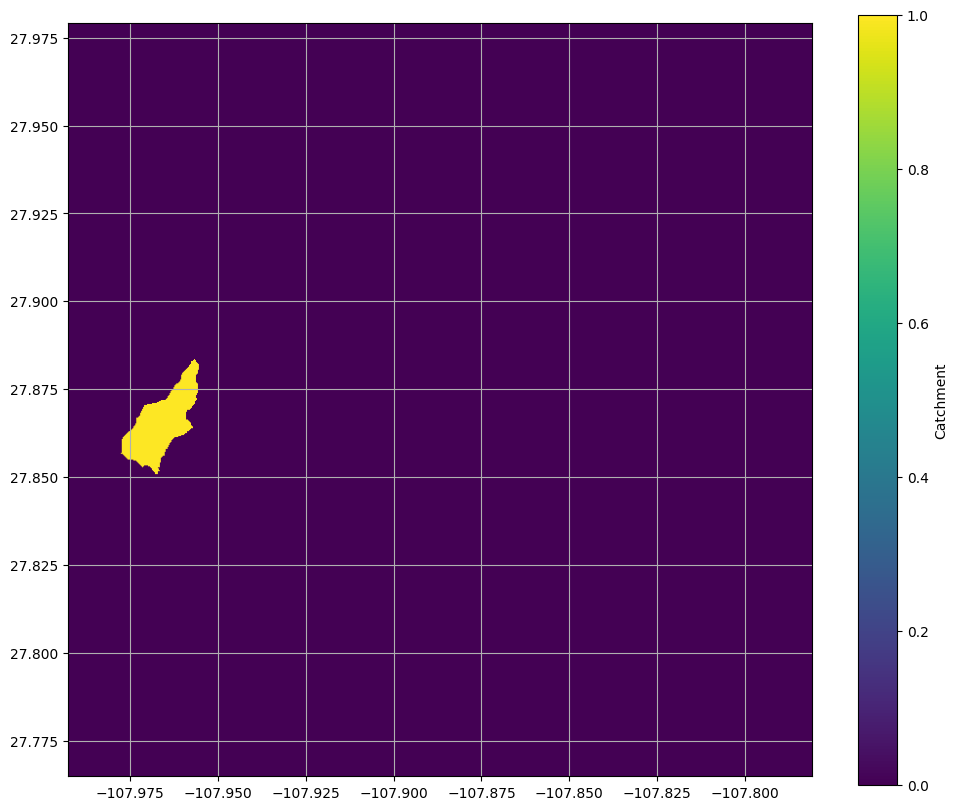

In [ ]:
# Specify pour point
x, y = -107.975, 27.850

# Snap pour point to high accumulation cell
x_snap, y_snap = grid.snap_to_mask(acc > 1000, (x, y))

# Delineate the catchment
catch2 = grid.catchment(fdir=fdir, x=x_snap, y=y_snap, recursionlimit=15000, xytype='coordinate', nodata_out=0)
plotFigure(catch2, 'Catchment', 'Greys_r')

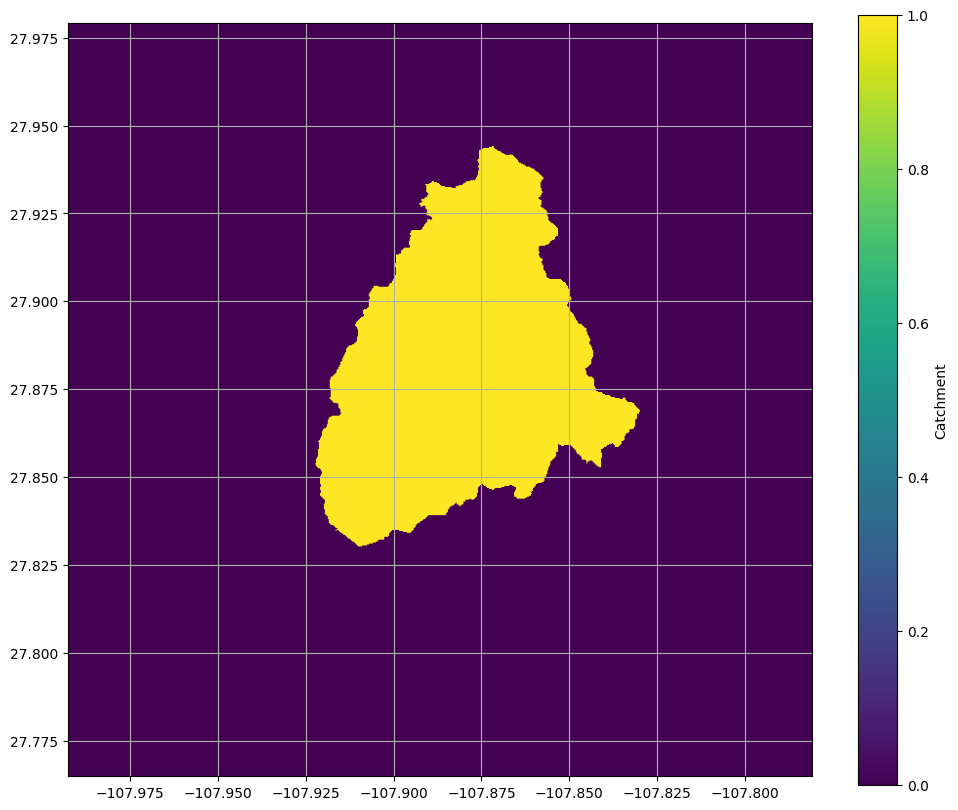

In [ ]:
# Specify discharge point
x, y = -107.91663,27.83479

# Delineate the catchment
catch = grid.catchment(fdir=fdir, x=x, y=y, recursionlimit=15000, xytype='label', nodata_out=0)
plotFigure(catch, 'Catchment', 'Greys_r')

In [ ]:
# Crop and plot the catchment
# ---------------------------
# Clip the bounding box to the catchment
grid.clip_to(catch)

Text(0.5, 1.0, 'Delineated Catchment')

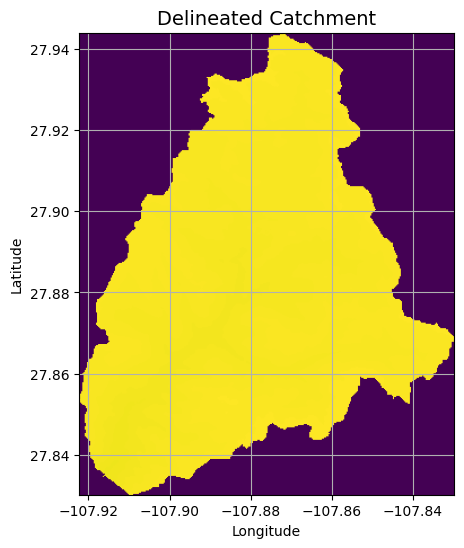

In [ ]:
# Get a view of the catchment
clipped_catch = grid.view(elevDem)

# Plot the catchment
fig, ax = plt.subplots(figsize=(8,6))
fig.patch.set_alpha(0)

plt.grid('on', zorder=0)
im = ax.imshow(np.where(clipped_catch, clipped_catch, np.nan), extent=grid.extent,
               zorder=1)
plt.xlabel('Longitude')
plt.ylabel('Latitude')
plt.title('Delineated Catchment', size=14)

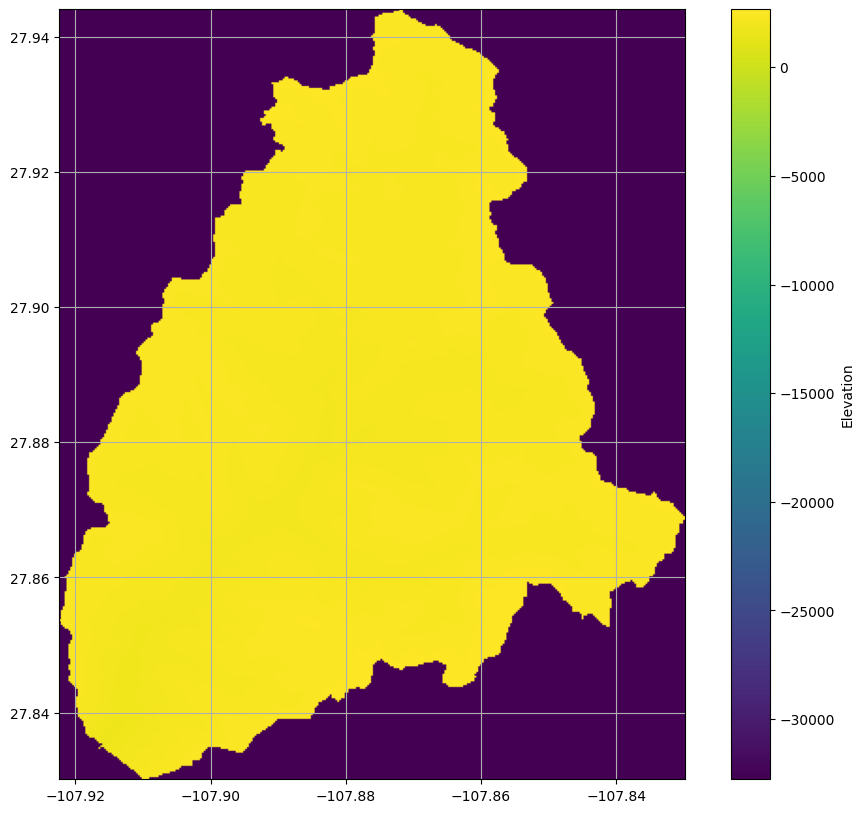

In [ ]:
plotFigure(clipped_catch,'Elevation')

In [ ]:
#export selected raster
grid.to_raster(demView, '../Output/clippedElevations.tif')

NameError: name 'demView' is not defined

Text(0.5, 1.0, 'Flow Distance')

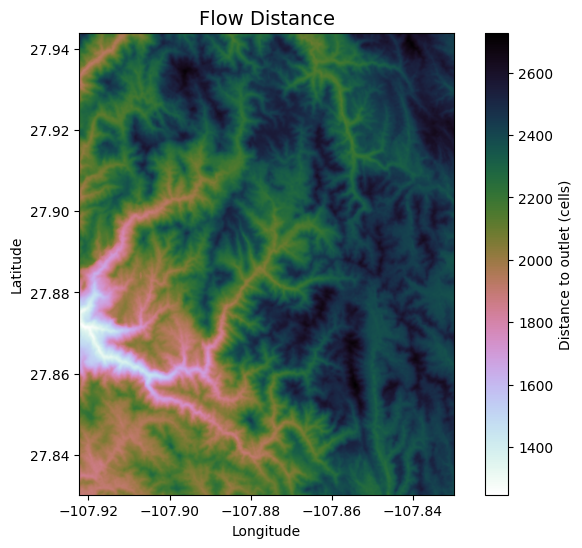

In [ ]:
fig, ax = plt.subplots(figsize=(8,6))
fig.patch.set_alpha(0)
plt.grid('on', zorder=0)
im = ax.imshow(elevDem, extent=clipped_catch.extent, zorder=2,
               cmap='cubehelix_r')
plt.colorbar(im, ax=ax, label='Distance to outlet (cells)')
plt.xlabel('Longitude')
plt.ylabel('Latitude')
plt.title('Flow Distance', size=14)

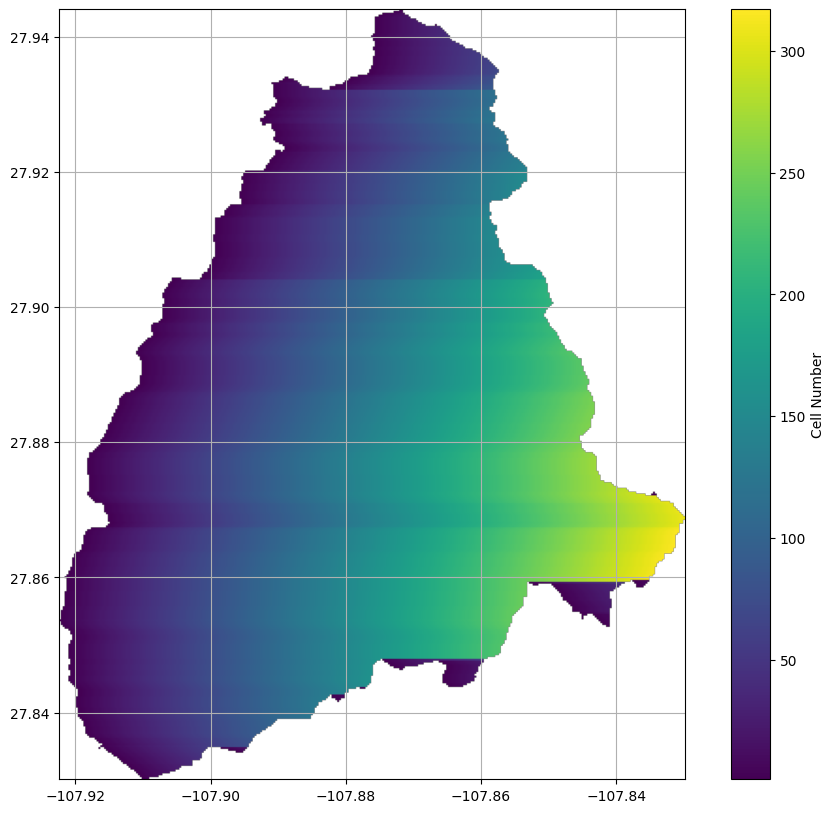

In [ ]:
accCatch = grid.accumulation(catch, dirmap=dirmap, pad_inplace=False)
accView = grid.view(accCatch, nodata=np.nan)
plotFigure(accView,"Cell Number",'PuRd')

In [ ]:
streams = grid.extract_river_network('catch', 'acc', threshold=200, dirmap=dirmap)
streams["features"][:2]

[{"geometry": {"coordinates": [[-107.86763888888879, 27.93319444444552], [-107.86763888888879, 27.933472222223298], [-107.86763888888879, 27.933750000001073], [-107.86791666666657, 27.93402777777885], [-107.86791666666657, 27.93430555555663], [-107.86791666666657, 27.93458333333441], [-107.86791666666657, 27.934861111112188], [-107.86791666666657, 27.935138888889963], [-107.86791666666657, 27.93541666666774], [-107.86791666666657, 27.93569444444552], [-107.86791666666657, 27.9359722222233], [-107.86763888888879, 27.936250000001078], [-107.86763888888879, 27.936527777778853], [-107.86736111111101, 27.93680555555663], [-107.86736111111101, 27.93708333333441], [-107.86708333333324, 27.93736111111219], [-107.86708333333324, 27.937638888889968], [-107.86708333333324, 27.937916666667743], [-107.86708333333324, 27.93819444444552], [-107.86736111111101, 27.9384722222233], [-107.86736111111101, 27.93875000000108], [-107.86763888888879, 27.939027777778858], [-107.86763888888879, 27.9393055555566

In [ ]:
def saveDict(dic,file):
    f = open(file,'w')
    f.write(str(dic))
    f.close()

In [ ]:
#save geojson as separate file
saveDict(streams,'../Output/streams_WGS84.geojson')

In [ ]:
streamNet = gpd.read_file('../Output/streams_WGS84.geojson')
streamNet.crs = {'init' :'epsg:4326'}

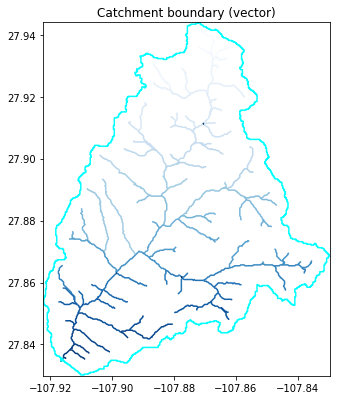

In [ ]:
# The polygonize argument defaults to the grid mask when no arguments are supplied
shapes = grid.polygonize()

# Plot catchment boundaries
fig, ax = plt.subplots(figsize=(6.5, 6.5))

for shape in shapes:
    coords = np.asarray(shape[0]['coordinates'][0])
    ax.plot(coords[:,0], coords[:,1], color='cyan')
    
ax.set_xlim(grid.bbox[0], grid.bbox[2])
ax.set_ylim(grid.bbox[1], grid.bbox[3])
ax.set_title('Catchment boundary (vector)')
gpd.plotting.plot_dataframe(streamNet, None, cmap='Blues', ax=ax)

In [ ]:
#ax = streamNet.plot()
mplleaflet.display(fig=ax.figure, crs=streamNet.crs, tiles='esri_aerial')

In [32]:
grid = Grid.from_raster('../Rst/20190109125130_1063922483.tif', data_name='dem')
grid.read_raster('../Rst/20190109125130_1063922483.tif', data_name='dir')


         #N    NE    E    SE    S    SW    W    NW
dirmap = (64,  128,  1,   2,    4,   8,    16,  32)

# Specify pour point
x, y = -97.294167, 32.73750

# Delineate the catchment
grid.catchment(data='dir', x=x, y=y, dirmap=dirmap, out_name='catch',
               recursionlimit=15000, xytype='label', nodata_out=0)

# Clip to catchment
grid.clip_to('catch')


# Calling grid.polygonize without arguments will default to the catchment mask
shapes = grid.polygonize()

# Is equivalent to...
shapes = grid.polygonize(grid.mask.astype(np.uint8))


TypeError: sGrid.catchment() missing 1 required positional argument: 'fdir'